In [ ]:
from FastBEMT.Propeller import Propeller
from FastBEMT.JobParameters import LowFidelityParameters
from FastBEMT.Plotter import Plotter
from FastBEMT.DataLoader import *
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
plt.style.use(['science', 'no-latex'])

In [2]:
# prop_name, blade_dict = load_propeller_dict('SignedStress/run_001/Pareto20')[0]
prop_name, blade_dict = load_propeller_dict('10x7E')[0]

In [3]:
params = LowFidelityParameters(
    rpm=7000,
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
    n_blades=blade_dict['n_blades'],
    p_ref=2e-5,
    revolutions=5,
    num_obs_times_per_rev=100,
    device='cuda'
)

In [18]:
import torch 
from PropGen.GAN import GAN
from PropGen.BladeDictGenerator import generate_blade_dict

x = torch.tensor([7.1524e-01, 5.1678e-01, 6.8234e-01, 3.9817e-01, 5.9171e-01, 6.8785e-01,
        1.0483e-01, 5.5052e-02, 2.1787e-01, 3.9872e-01, 3.9974e-02, 1.6425e-01,
        1.6758e-01, 1.1026e-01, 1.2555e-01, 9.1656e-01, 2.5215e-02, 1.3157e+01,
        2.6159e-03, 1.3555e-02, 2.7592e+01, 2.5621e+00, 8.7114e+00],
       dtype=torch.float64)

gan = GAN(latent_dim=8, noise_dim=0)
gan.load_checkpoint('N:/Teams/Groups/ThermalSim/Projects/Public/AirfoilGAN Models/WGAN_LCR1/latent8_noise0/checkpoint_50000.pth')
# gan.load_checkpoint('C:/Users/Davide Pusino/Desktop/PropGen/Datasets/checkpoint_50000.pth')

blade_dict = generate_blade_dict(
    x=x,
    parametrization='parametric',
    gan=gan,
    r_hub=0.02794,
    r_tip=0.127,
)

Successfully loaded checkpoint from step 50000


In [19]:
nx, ny = 26, 26
size = 5

In [20]:
x_range = np.linspace(-size, size, nx)
y_range = np.linspace(0, size, ny)
X, Y = np.meshgrid(x_range, y_range)
Z = np.zeros_like(X) 

r_observers = np.stack([X.flatten(), Y.flatten(), Z.flatten()], axis=1)

propeller = Propeller(
    geometry=blade_dict,
    params=params,
)

propeller.run_bemt(v_inf=0.0)

C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Section.py:401: UserWarning: Root finding did not converge at r = 0.12373133333333336
  warnings.warn(f"Root finding did not converge at r = {self.r}")


In [21]:
thrust, _torque, ct, cq = propeller.compute_total_forces()
figure_of_merit = np.sqrt(2 / np.pi) * ct**1.5 / 2 / np.pi / cq

In [22]:
figure_of_merit

np.float64(0.44843377490987746)

In [23]:
propeller.run_aeroacoustics(observer_positions=r_observers,
        lt=1,
        i=1e-3,
        alpha_stall=15,
        keep_bpm_components=False)

propeller.postprocess()

[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 5.402 ms
[CUDA TIMING] BPM.__init__: 0.788 ms
[CUDA TIMING] get_observer_times: 6.530 ms
[CUDA TIMING] calculate_f1a_pressure: 225.265 ms
[CUDA TIMING] combine_sources (F1A): 49.194 ms
[CUDA TIMING] _perform_spectral_analysis_torch: 5.431 ms
[CUDA TIMING] BPM.run_forward_bpm: 1447.236 ms
[CUDA TIMING] combine_sources_bpm: 0.838 ms


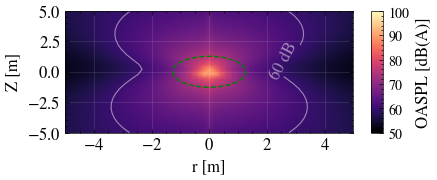

In [24]:
plotter = Plotter(propeller)
plotter.plot_acoustic_map(
    grid_size=nx,
    domain_size=size,
    figsize=(4.5, 2),
    cmap='magma',
    show_contours=True,
    save_path='../Figures/acoustic_map10x7E.pdf'
)